In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_regression, f_classif
from sklearn.feature_selection import SelectKBest
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
dataset= pd.read_csv('C:/Users/maame/Downloads/IT_Company_Time_Series.csv')
dataset.head()

,Date,Software_1,Software_2,Software_3,Software_4,Software_5,Software_6,Software_7,Software_8,Software_9,Software_10,Software_11,Software_12,Software_13,Software_14,Software_15
0,2018-01-31,104,97,63,72,50,95,101,63,134,101,72,134,118,95,114
1,2018-02-28,89,128,61,95,52,97,113,73,144,117,68,110,115,79,131
2,2018-03-31,114,101,75,85,45,96,120,75,142,109,69,110,117,74,84
3,2018-04-30,107,94,44,85,35,99,112,75,135,98,59,137,101,72,98
4,2018-05-31,92,104,66,97,48,81,108,81,138,89,64,124,107,83,122


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         60 non-null     object
 1   Software_1   60 non-null     int64 
 2   Software_2   60 non-null     int64 
 3   Software_3   60 non-null     int64 
 4   Software_4   60 non-null     int64 
 5   Software_5   60 non-null     int64 
 6   Software_6   60 non-null     int64 
 7   Software_7   60 non-null     int64 
 8   Software_8   60 non-null     int64 
 9   Software_9   60 non-null     int64 
 10  Software_10  60 non-null     int64 
 11  Software_11  60 non-null     int64 
 12  Software_12  60 non-null     int64 
 13  Software_13  60 non-null     int64 
 14  Software_14  60 non-null     int64 
 15  Software_15  60 non-null     int64 
dtypes: int64(15), object(1)
memory usage: 7.6+ KB


In [4]:
dataset.shape

(60, 16)

In [5]:
# Checking for missing values.
dataset.isnull().sum()

Date           0
Software_1     0
Software_2     0
Software_3     0
Software_4     0
Software_5     0
Software_6     0
Software_7     0
Software_8     0
Software_9     0
Software_10    0
Software_11    0
Software_12    0
Software_13    0
Software_14    0
Software_15    0
dtype: int64

In [6]:
#Converting the Date column into the index
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset.set_index('Date', inplace = True)

In [7]:
# Statistics summary of the dataset
dataset.describe()

,Software_1,Software_2,Software_3,Software_4,Software_5,Software_6,Software_7,Software_8,Software_9,Software_10,Software_11,Software_12,Software_13,Software_14,Software_15
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,99.966667,102.283333,64.116667,88.116667,51.883333,89.900000,109.766667,67.800000,128.183333,94.216667,71.100000,122.750000,116.166667,78.733333,104.333333
std,9.596904,10.551073,8.574878,10.764177,7.309366,8.482684,8.803633,9.136999,11.985149,8.592649,8.274322,11.194165,10.371353,7.804533,12.743449
min,81.000000,79.000000,44.000000,66.000000,35.000000,71.000000,93.000000,48.000000,89.000000,70.000000,57.000000,100.000000,95.000000,60.000000,72.000000
25%,92.000000,94.750000,58.000000,82.500000,47.000000,84.000000,102.750000,62.750000,121.750000,89.750000,65.000000,115.000000,108.750000,72.750000,96.000000
50%,101.000000,103.000000,65.000000,88.000000,51.000000,90.000000,111.500000,68.500000,129.000000,93.000000,71.000000,121.000000,116.500000,79.000000,105.000000
75%,107.000000,107.750000,69.000000,94.250000,55.500000,96.000000,116.250000,74.000000,136.000000,98.000000,77.000000,129.000000,122.250000,84.000000,116.000000
max,118.000000,128.000000,87.000000,114.000000,73.000000,106.000000,126.000000,90.000000,153.000000,117.000000,94.000000,161.000000,149.000000,95.000000,131.000000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2018-01-31 to 2022-12-31
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Software_1   60 non-null     int64
 1   Software_2   60 non-null     int64
 2   Software_3   60 non-null     int64
 3   Software_4   60 non-null     int64
 4   Software_5   60 non-null     int64
 5   Software_6   60 non-null     int64
 6   Software_7   60 non-null     int64
 7   Software_8   60 non-null     int64
 8   Software_9   60 non-null     int64
 9   Software_10  60 non-null     int64
 10  Software_11  60 non-null     int64
 11  Software_12  60 non-null     int64
 12  Software_13  60 non-null     int64
 13  Software_14  60 non-null     int64
 14  Software_15  60 non-null     int64
dtypes: int64(15)
memory usage: 7.5 KB


<Axes: >

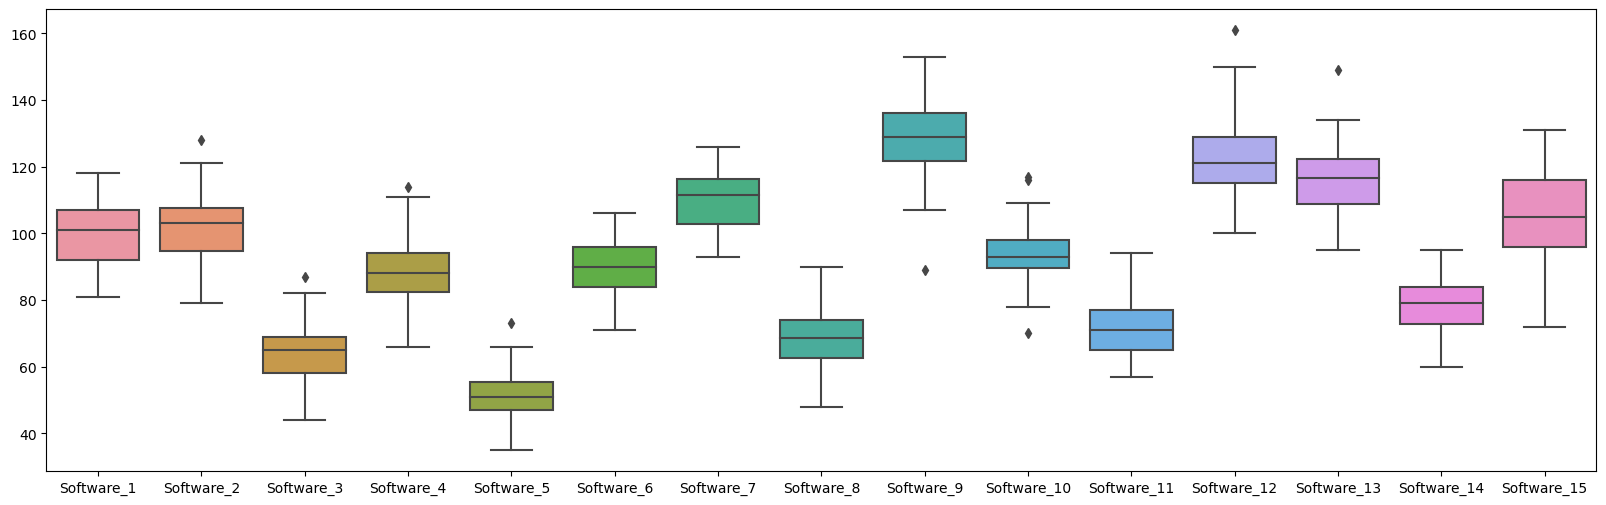

In [8]:
# Checking for outliers
df_box = dataset
df_box.info()
plt.figure(figsize=(20, 6)) 
sns.boxplot(data = df_box)


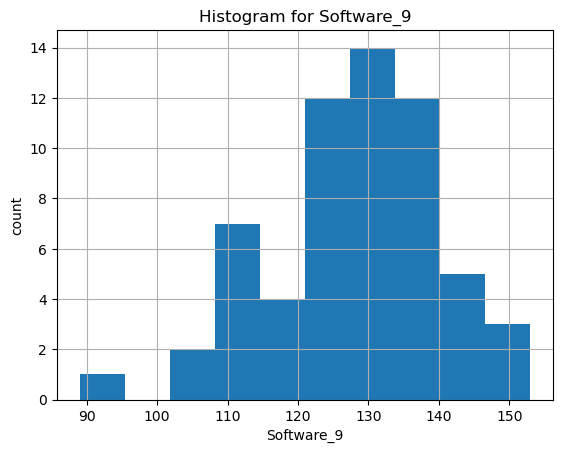

In [9]:
# checking distribution for software 9
plt.hist(dataset['Software_9'],bins=10, )
plt.title('Histogram for Software_9')
plt.xlabel('Software_9')
plt.ylabel('count')
plt.grid(True)
plt.show()
              
           

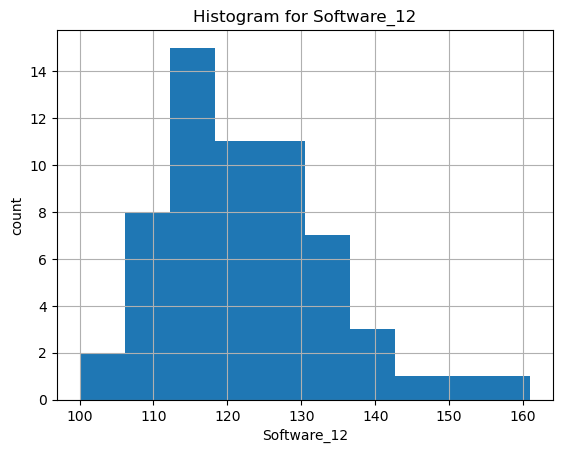

In [10]:
# checking distribution for software 12
plt.hist(dataset['Software_12'],bins=10, )
plt.title('Histogram for Software_12')
plt.xlabel('Software_12')
plt.ylabel('count')
plt.grid(True)
plt.show()
              
           

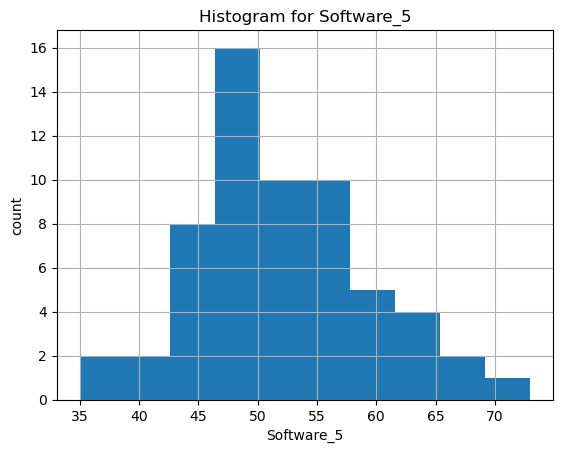

In [11]:
# checking distribution for software 5
plt.hist(dataset['Software_5'],bins=10, )
plt.title('Histogram for Software_5')
plt.xlabel('Software_5')
plt.ylabel('count')
plt.grid(True)
plt.show()

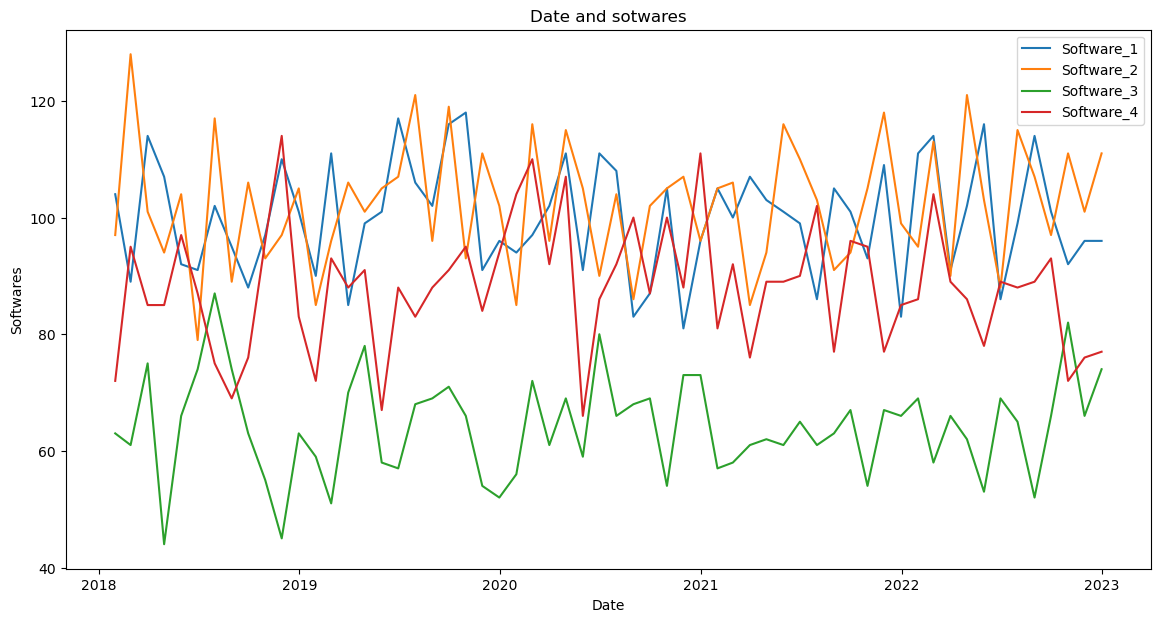

In [12]:
plt.figure(figsize = (14,7))
plt.plot(dataset.index, dataset['Software_1'], label = 'Software_1')
plt.plot(dataset.index, dataset['Software_2'], label = 'Software_2')
plt.plot(dataset.index, dataset['Software_3'], label = 'Software_3')
plt.plot(dataset.index, dataset['Software_4'], label = 'Software_4')
plt.xlabel('Date')
plt.ylabel('Softwares')
plt.title('Date and sotwares')
plt.legend()


In [13]:
#### encode all the object and convert as categories
### dataset_cat.select_dtypes(include=['object']).columns

catcol = dataset.select_dtypes(include=['object']).columns

In [14]:
catcol

Index([], dtype='object')

In [15]:
#### Encoding 
#### create categories for type cat columns 
dataset_cat=dataset.copy()

In [16]:
for col in catcol:
    dataset_cat[col]=dataset_cat[col].astype('category').cat.codes

In [17]:
dataset_cat

,Software_1,Software_2,Software_3,Software_4,Software_5,Software_6,Software_7,Software_8,Software_9,Software_10,Software_11,Software_12,Software_13,Software_14,Software_15
Date,,,,,,,,,,,,,,,
2018-01-31,104,97,63,72,50,95,101,63,134,101,72,134,118,95,114
2018-02-28,89,128,61,95,52,97,113,73,144,117,68,110,115,79,131
2018-03-31,114,101,75,85,45,96,120,75,142,109,69,110,117,74,84
2018-04-30,107,94,44,85,35,99,112,75,135,98,59,137,101,72,98
2018-05-31,92,104,66,97,48,81,108,81,138,89,64,124,107,83,122
2018-06-30,91,79,74,87,41,104,99,73,114,116,61,117,122,80,99
2018-07-31,102,117,87,75,52,91,107,72,137,104,94,113,116,60,104
2018-08-31,95,89,74,69,50,88,115,69,141,94,73,115,108,86,86
2018-09-30,88,106,63,76,57,103,118,63,129,96,80,100,102,80,76


In [18]:
dataset_cat.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2018-01-31 to 2022-12-31
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Software_1   60 non-null     int64
 1   Software_2   60 non-null     int64
 2   Software_3   60 non-null     int64
 3   Software_4   60 non-null     int64
 4   Software_5   60 non-null     int64
 5   Software_6   60 non-null     int64
 6   Software_7   60 non-null     int64
 7   Software_8   60 non-null     int64
 8   Software_9   60 non-null     int64
 9   Software_10  60 non-null     int64
 10  Software_11  60 non-null     int64
 11  Software_12  60 non-null     int64
 12  Software_13  60 non-null     int64
 13  Software_14  60 non-null     int64
 14  Software_15  60 non-null     int64
dtypes: int64(15)
memory usage: 7.5 KB


In [19]:
dataset.isnull().sum()

Software_1     0
Software_2     0
Software_3     0
Software_4     0
Software_5     0
Software_6     0
Software_7     0
Software_8     0
Software_9     0
Software_10    0
Software_11    0
Software_12    0
Software_13    0
Software_14    0
Software_15    0
dtype: int64

# Q2

In [20]:
dataset.head()

,Software_1,Software_2,Software_3,Software_4,Software_5,Software_6,Software_7,Software_8,Software_9,Software_10,Software_11,Software_12,Software_13,Software_14,Software_15
Date,,,,,,,,,,,,,,,
2018-01-31,104,97,63,72,50,95,101,63,134,101,72,134,118,95,114
2018-02-28,89,128,61,95,52,97,113,73,144,117,68,110,115,79,131
2018-03-31,114,101,75,85,45,96,120,75,142,109,69,110,117,74,84
2018-04-30,107,94,44,85,35,99,112,75,135,98,59,137,101,72,98
2018-05-31,92,104,66,97,48,81,108,81,138,89,64,124,107,83,122


In [21]:
# Another column was created called Total.

dataset['Total'] = dataset.loc[:,dataset.columns != 'Year'].sum(axis = 1)

In [22]:
dataset.head()

,Software_1,Software_2,Software_3,Software_4,Software_5,Software_6,Software_7,Software_8,Software_9,Software_10,Software_11,Software_12,Software_13,Software_14,Software_15,Total
Date,,,,,,,,,,,,,,,,
2018-01-31,104,97,63,72,50,95,101,63,134,101,72,134,118,95,114,1413
2018-02-28,89,128,61,95,52,97,113,73,144,117,68,110,115,79,131,1472
2018-03-31,114,101,75,85,45,96,120,75,142,109,69,110,117,74,84,1416
2018-04-30,107,94,44,85,35,99,112,75,135,98,59,137,101,72,98,1351
2018-05-31,92,104,66,97,48,81,108,81,138,89,64,124,107,83,122,1404


In [23]:
#Consider as a new df picking the variable i will be working with

df_Total= dataset[['Total']]

In [24]:
# Ducky Fuller Test to check the stationarity/seasonality of the data

# H0: the data is not stationary
# H1 : the data is stationary
#alpha = 0.05

result = adfuller(df_Total['Total'])
print('ADF statistics:', result[0])
print('p-value:', result[1])

ADF statistics: -6.312716405221322
p-value: 3.205309121239001e-08


In [25]:
#Splitting the data into training and testing set

train_size = int(len(df_Total)*0.8)
train,test = df_Total.iloc[:train_size], df_Total.iloc[train_size:]

In [26]:
#Defining the ARIMA model
order_Total = (1, 1, 1) # (p, d, q)
model_Total = ARIMA(train['Total'], order = order_Total)
results_Total = model_Total.fit()

C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [27]:
#Forecasting for the testing size
forecast_steps_test = len(test)
forecast_Total_test = results_Total.get_forecast(steps = forecast_steps_test)
forecast_values_test = forecast_Total_test.predicted_mean
forecast_values_test.index = test.index

In [28]:
#We will make predictions for the next 30 days

forecast_steps_30= 30
forecast_Total_30 = results_Total.get_forecast(steps= forecast_steps_30)
forecast_df_30 = pd.DataFrame({
    'Forecast': forecast_Total_30.predicted_mean.round() 
})
forecast_df_30.index = pd.date_range(start = test.index[-1] + pd.Timedelta(days = 7), periods = forecast_steps_30, freq= 'W')


In [29]:
#We can calculate the MAPE (performance of the model, if it is close to zero is better)

#To avoid issues dividing something by zero, we need to do some extra step

non_zero_test = test['Total'] !=0
filtered_test = test['Total'][non_zero_test]
filtered_forecast = forecast_values_test[non_zero_test]
mape = np.mean(np.abs((filtered_test - filtered_forecast)/filtered_test))*100
mape

1.8950469541895099

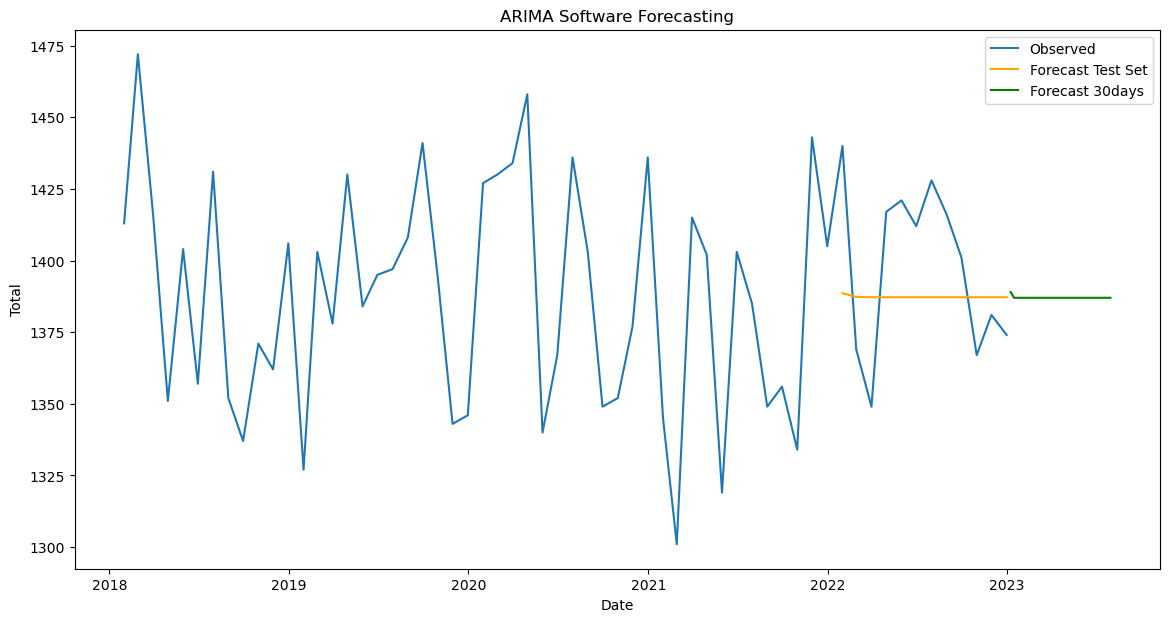

In [30]:
#Plotting the results and the data

plt.figure(figsize=(14,7))

#Observed values and forecast for the test set
plt.plot(df_Total.index, df_Total['Total'], label = 'Observed')
plt.plot(forecast_values_test.index, forecast_values_test, label = 'Forecast Test Set', color = 'orange')

#Forecast for the next 30days
plt.plot(forecast_df_30.index, forecast_df_30['Forecast'], label = 'Forecast 30days', color = 'green')

plt.title('ARIMA Software Forecasting')
plt.xlabel('Date')
plt.ylabel('Total')
plt.legend()
plt.show()

In [31]:
#Displaying the data in a table

forecast_df_30

,Forecast
2023-01-08,1389.0
2023-01-15,1387.0
2023-01-22,1387.0
2023-01-29,1387.0
2023-02-05,1387.0
2023-02-12,1387.0
2023-02-19,1387.0
2023-02-26,1387.0
2023-03-05,1387.0
2023-03-12,1387.0


In [32]:
#Defining the SARIMAX model
order_Total = (1,1,1) #p, d, q --> as in the ARIMA model
seasonal_order_Total = (1, 1, 1, 52) #we have the SARIMAX parameters (P, D, Q, S --> season)


In [33]:
model_Total = SARIMAX(train['Total'], order = order_Total, seasonal_order = seasonal_order_Total)
results_Total = model_Total.fit()

C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\maame\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [34]:
#Forecasting for the testing size
forecast_steps_test = len(test)
forecast_Total_test = results_Total.get_forecast(steps = forecast_steps_test)
forecast_values_test = forecast_Total_test.predicted_mean
forecast_values_test.index = test.index

In [35]:
#We will make predictions for the next 30 days

forecast_steps_30= 30
forecast_Total_30 = results_Total.get_forecast(steps= forecast_steps_30)
forecast_df_30 = pd.DataFrame({
    'Forecast': forecast_Total_30.predicted_mean.round() 
})
forecast_df_30.index = pd.date_range(start = test.index[-1] + pd.Timedelta(days = 7), periods = forecast_steps_30, freq= 'W')


In [36]:
#We can calculate the MAPE (performance of the model, if it is close to zero is better)

#To avoid issues dividing something by zero, we need to do some extra step

non_zero_test = test['Total'] !=0
filtered_test = test['Total'][non_zero_test]
filtered_forecast = forecast_values_test[non_zero_test]
mape = np.mean(np.abs((filtered_test - filtered_forecast)/filtered_test))*100
mape

34.087908578439055

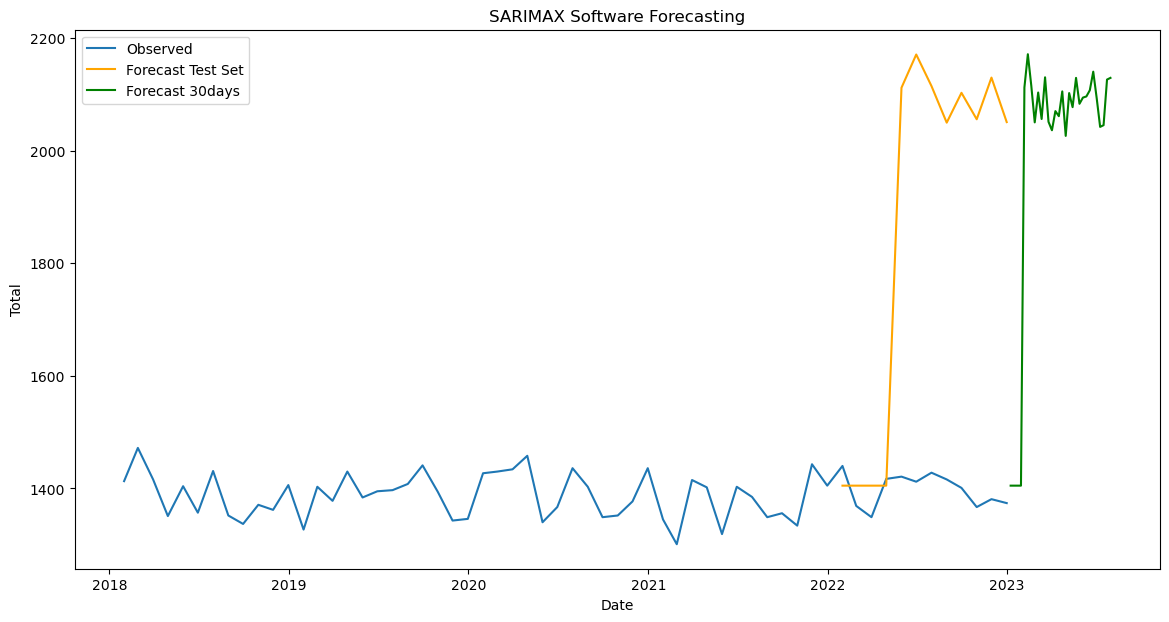

In [37]:
#Plotting the results and the data

plt.figure(figsize=(14,7))

#Observed values and forecast for the test set
plt.plot(df_Total.index, df_Total['Total'], label = 'Observed')
plt.plot(forecast_values_test.index, forecast_values_test, label = 'Forecast Test Set', color = 'orange')

#Forecast for the next 30days
plt.plot(forecast_df_30.index, forecast_df_30['Forecast'], label = 'Forecast 30days', color = 'green')

plt.title('SARIMAX Software Forecasting')
plt.xlabel('Date')
plt.ylabel('Total')
plt.legend()
plt.show()

In [38]:
forecast_df_30

,Forecast
2023-01-08,1405.0
2023-01-15,1405.0
2023-01-22,1405.0
2023-01-29,1405.0
2023-02-05,2112.0
2023-02-12,2171.0
2023-02-19,2115.0
2023-02-26,2050.0
2023-03-05,2103.0
2023-03-12,2056.0


# Q3

In [39]:
#Import isolation forest

from sklearn.ensemble import IsolationForest

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [41]:
dataset_classification= pd.read_csv('C:/Users/maame/Downloads/IT_Company_System_Issues_Classification.csv')
dataset_classification.head()

,Unnamed: 0,Issue_ID,Issue_Type,System_Component,Customer_Impact,Time_to_Resolve_hrs,Reported_By,Priority,Previous_Occurrences,Issue_Reported_Month,Resolved
0,0,8544,Hardware,Component_D,High,43.117583,Automated_System,High,2,Jul,True
1,1,6569,Server,Component_B,Low,71.695013,Customer,Low,6,May,False
2,2,3990,Server,Component_D,Medium,31.621253,Automated_System,Medium,4,Mar,False
3,3,3504,Server,Component_C,Low,66.329435,Automated_System,Medium,0,Sep,True
4,4,1587,Server,Component_D,Medium,25.168704,Automated_System,Medium,2,Jun,False


In [42]:
# checking data type
dataset_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1000 non-null   int64  
 1   Issue_ID              1000 non-null   int64  
 2   Issue_Type            1000 non-null   object 
 3   System_Component      1000 non-null   object 
 4   Customer_Impact       1000 non-null   object 
 5   Time_to_Resolve_hrs   1000 non-null   float64
 6   Reported_By           1000 non-null   object 
 7   Priority              1000 non-null   object 
 8   Previous_Occurrences  1000 non-null   int64  
 9   Issue_Reported_Month  1000 non-null   object 
 10  Resolved              1000 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 79.2+ KB


In [43]:
# checking missing values. No missing values
dataset_classification.isnull().sum()

Unnamed: 0              0
Issue_ID                0
Issue_Type              0
System_Component        0
Customer_Impact         0
Time_to_Resolve_hrs     0
Reported_By             0
Priority                0
Previous_Occurrences    0
Issue_Reported_Month    0
Resolved                0
dtype: int64

In [44]:
# Descriptive Statistics
dataset_classification.describe()


,Unnamed: 0,Issue_ID,Time_to_Resolve_hrs,Previous_Occurrences
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,5457.773000,35.758472,4.471000
std,288.819436,2530.039561,20.732766,3.023624
min,0.000000,1006.000000,0.516233,0.000000
25%,249.750000,3253.250000,17.931090,2.000000
50%,499.500000,5415.000000,34.537280,4.000000
75%,749.250000,7581.500000,53.575284,7.000000
max,999.000000,9988.000000,71.913695,9.000000


In [45]:
#Evaluating Customer impact from high to low
Customer_impact = dataset_classification['Customer_Impact'].value_counts()
Customer_impact

Customer_Impact
Low       350
Medium    329
High      321
Name: count, dtype: int64

In [46]:
Customer_impact_percentage = (Customer_impact/len(dataset_classification))*100


In [47]:
Customer_impact_percentage

Customer_Impact
Low       35.0
Medium    32.9
High      32.1
Name: count, dtype: float64

In [48]:
#Checking for Resolve rate
Resolve_rate = dataset_classification['Resolved'].mean()
print(f'Resolve_rate: {Resolve_rate: .2f}')

Resolve_rate:  0.52


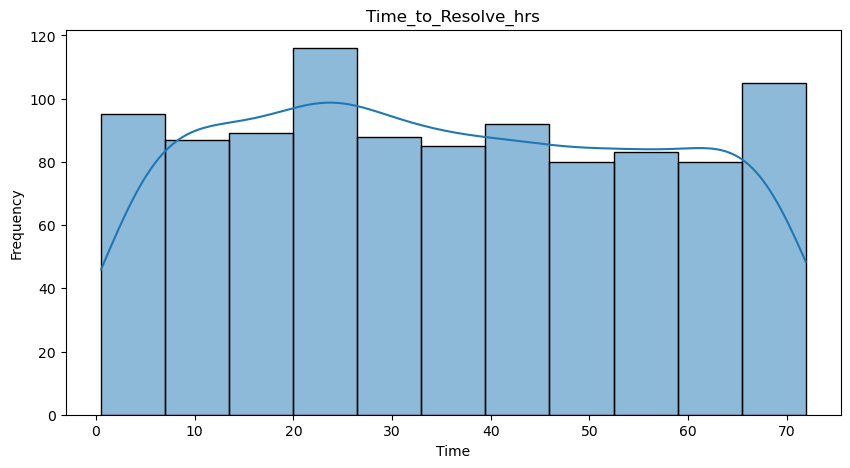

In [49]:
# visualising the data --> First: Histogram 

plt.figure(figsize=(10,5))
sns.histplot(dataset_classification['Time_to_Resolve_hrs'], kde = True)
plt.title('Time_to_Resolve_hrs')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

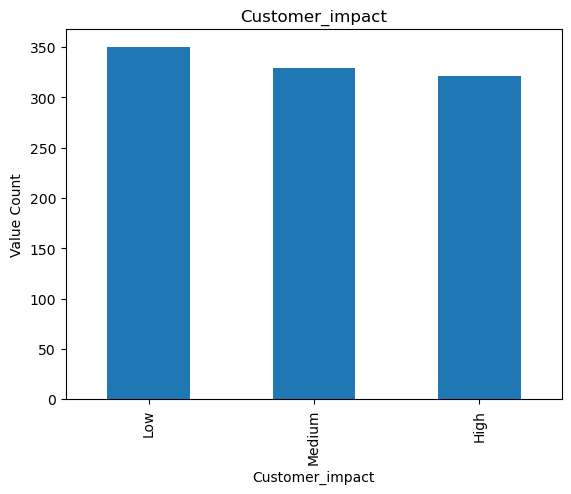

In [50]:
#Visualisation to show the customer_impact

Customer_impact = dataset_classification['Customer_Impact'].value_counts()
Customer_impact.plot(kind ='bar')
plt.title('Customer_impact')
plt.xlabel('Customer_impact')
plt.ylabel('Value Count')
plt.show()

In [51]:
dataset_classification.head()

,Unnamed: 0,Issue_ID,Issue_Type,System_Component,Customer_Impact,Time_to_Resolve_hrs,Reported_By,Priority,Previous_Occurrences,Issue_Reported_Month,Resolved
0,0,8544,Hardware,Component_D,High,43.117583,Automated_System,High,2,Jul,True
1,1,6569,Server,Component_B,Low,71.695013,Customer,Low,6,May,False
2,2,3990,Server,Component_D,Medium,31.621253,Automated_System,Medium,4,Mar,False
3,3,3504,Server,Component_C,Low,66.329435,Automated_System,Medium,0,Sep,True
4,4,1587,Server,Component_D,Medium,25.168704,Automated_System,Medium,2,Jun,False


In [52]:
# Encoding Categorical data
label_encoder = LabelEncoder()
dataset_classification['Issue_Type'] = label_encoder.fit_transform(dataset_classification['Issue_Type'])
dataset_classification['System_Component'] = label_encoder.fit_transform(dataset_classification['System_Component'])
dataset_classification['Customer_Impact'] = label_encoder.fit_transform(dataset_classification['Customer_Impact'])
dataset_classification['Resolved'] = label_encoder.fit_transform(dataset_classification['Resolved'])

dataset_classification.head()

,Unnamed: 0,Issue_ID,Issue_Type,System_Component,Customer_Impact,Time_to_Resolve_hrs,Reported_By,Priority,Previous_Occurrences,Issue_Reported_Month,Resolved
0,0,8544,0,3,0,43.117583,Automated_System,High,2,Jul,1
1,1,6569,2,1,1,71.695013,Customer,Low,6,May,0
2,2,3990,2,3,2,31.621253,Automated_System,Medium,4,Mar,0
3,3,3504,2,2,1,66.329435,Automated_System,Medium,0,Sep,1
4,4,1587,2,3,2,25.168704,Automated_System,Medium,2,Jun,0


In [53]:
features=['Issue_ID','Issue_Type','System_Component','Customer_Impact','Resolved']
dataset_classification.describe()
dataset_encoded=dataset_classification[features].copy()

In [54]:
dataset_encoded

,Issue_ID,Issue_Type,System_Component,Customer_Impact,Resolved
0,8544,0,3,0,1
1,6569,2,1,1,0
2,3990,2,3,2,0
3,3504,2,2,1,1
4,1587,2,3,2,0
...,...,...,...,...,...
995,8162,1,2,2,0
996,7241,0,3,0,0
997,9399,2,0,1,0
998,6633,2,2,2,1


In [55]:
X = dataset_encoded.iloc[:,:-1].values 
y = dataset_encoded.iloc[:, -1].values   

In [56]:
#Splitting into training and test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [57]:
#Feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [131]:
# Initialising the classifiers

classifiers = {
    'SVM Classifier': SVC(),
    'Random Forest Classifier': RandomForestClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'KNN Classifier': KNeighborsClassifier(),
    'Naive Bayes Classifier': GaussianNB()
}

In [132]:
# Training and evaluting the models

# this is just the accuracy results

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
#Print the results
for name, accuracy in results.items():
    print(f"{name}:{accuracy:.10f}")

SVM Classifier:0.5120000000
Random Forest Classifier:0.5040000000
Decision Tree Classifier:0.5000000000
KNN Classifier:0.5600000000
Naive Bayes Classifier:0.5120000000


# Q4

In [60]:
#With 10% contamination

#We define the features for anomaly detection
features=['Issue_Type','System_Component','Customer_Impact','Time_to_Resolve_hrs','Resolved']

In [61]:
# isolation forest was conducted
iso_forest = IsolationForest( contamination = 0.1, random_state = 0)

In [62]:
#We train the model
iso_forest.fit(dataset_classification[features])

IsolationForest(contamination=0.1, random_state=0)

In [63]:
#Predict anomalies
dataset_classification['Anomaly'] = iso_forest.predict(dataset_classification[features])

In [64]:
#Convert the anomaly labels (-1 for anomalies and 1 for normal values)

dataset_classification['Anomaly'] = dataset_classification['Anomaly'].map({1:0, -1:1})

In [65]:
anomalies = dataset_classification[dataset_classification['Anomaly'] ==1]
anomalies

,Unnamed: 0,Issue_ID,Issue_Type,System_Component,Customer_Impact,Time_to_Resolve_hrs,Reported_By,Priority,Previous_Occurrences,Issue_Reported_Month,Resolved,Anomaly
9,9,9381,1,0,0,0.516233,Automated_System,Medium,4,Apr,1,1
15,15,3326,2,0,2,5.333740,Customer,Medium,1,Sep,0,1
19,19,2674,0,3,2,9.018558,Customer,Urgent,9,Apr,0,1
27,27,7344,3,2,0,71.594617,Automated_System,Urgent,7,Jun,1,1
29,29,7144,3,3,2,4.348883,Automated_System,High,0,Apr,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
930,930,2481,3,0,0,2.402498,Customer,Urgent,3,Nov,0,1
942,942,5690,3,3,2,69.335380,Customer,Low,6,Mar,0,1
952,952,3949,0,1,2,4.519294,Automated_System,Medium,0,Jul,0,1
959,959,1887,0,1,2,2.889785,Automated_System,High,8,Jan,1,1


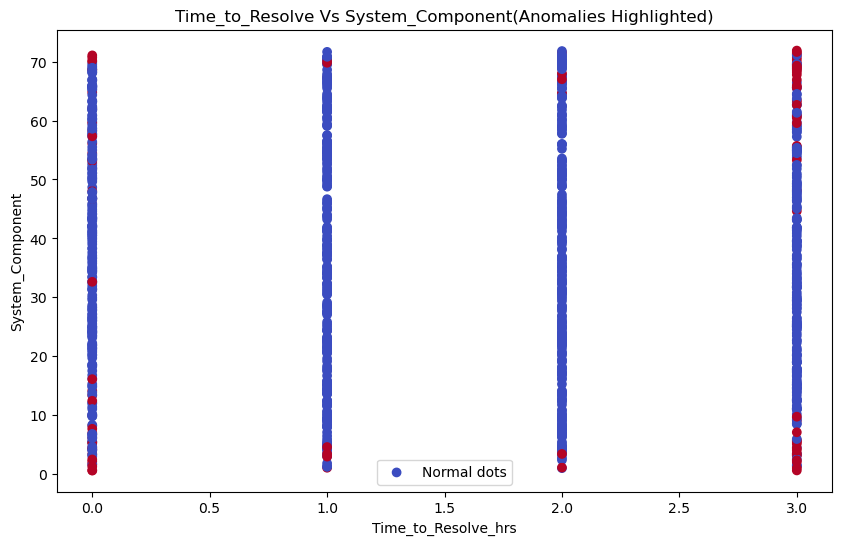

In [66]:
# Plot anomalies
plt.figure(figsize=(10, 6))
plt.scatter(dataset_classification['System_Component'], dataset_classification['Time_to_Resolve_hrs'], 
            c=dataset_classification['Anomaly'], cmap='coolwarm', label='Normal dots')
plt.xlabel('Time_to_Resolve_hrs')
plt.ylabel('System_Component')
plt.title('Time_to_Resolve Vs System_Component(Anomalies Highlighted)')
plt.legend()
plt.show()

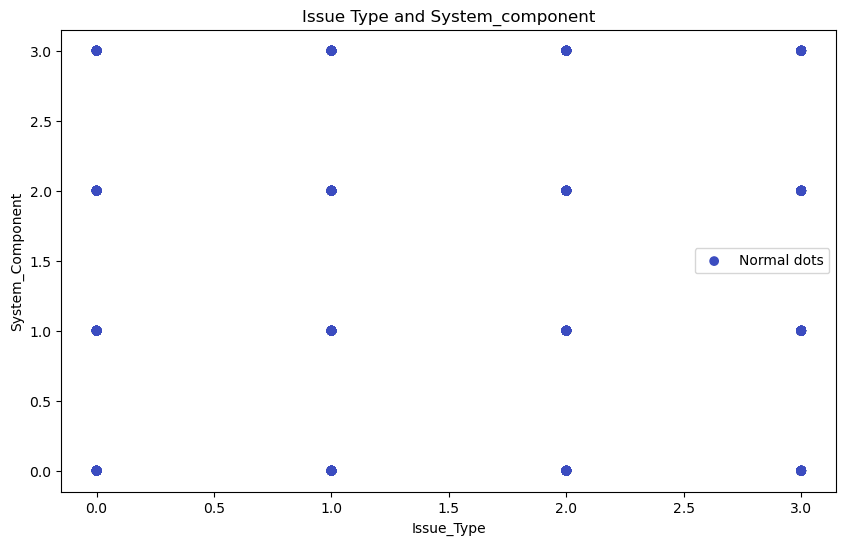

In [115]:
# Plot anomalies
plt.figure(figsize=(10, 6))
plt.scatter(dataset_classification['Issue_Type'], dataset_classification['System_Component'], 
            c=dataset_classification['Anomaly'], cmap='coolwarm', label='Normal dots')
plt.xlabel('Issue_Type')
plt.ylabel('System_Component')
plt.title('Issue Type and System_component')
plt.legend()
plt.show()

In [68]:
#We define the features for anomaly detection
features=['Issue_Type','System_Component','Customer_Impact','Resolved']

In [69]:
X_anomaly = dataset_classification[features]

In [70]:
#We start the isolation forest

anomaly_detector = IsolationForest(random_state = 0)

In [71]:
#We train the model

anomaly_detector.fit(X_anomaly)

IsolationForest(random_state=0)

In [72]:
#We obtain the anomaly scores

anomaly_scores = anomaly_detector.decision_function(X_anomaly)
dataset_classification['Anomaly_Score']= anomaly_scores

In [73]:
#We set a threshold

threshold = anomaly_scores.mean() - 2* anomaly_scores.std()
dataset_classification['Anomaly'] = dataset_classification['Anomaly_Score']<threshold

In [74]:
anomaly_results = dataset_classification[dataset_classification['Anomaly'] ==True]
anomaly_results

,Unnamed: 0,Issue_ID,Issue_Type,System_Component,Customer_Impact,Time_to_Resolve_hrs,Reported_By,Priority,Previous_Occurrences,Issue_Reported_Month,Resolved,Anomaly,Anomaly_Score


In [75]:
anomaly_results = dataset_classification[dataset_classification['Anomaly']]
anomaly_results

,Unnamed: 0,Issue_ID,Issue_Type,System_Component,Customer_Impact,Time_to_Resolve_hrs,Reported_By,Priority,Previous_Occurrences,Issue_Reported_Month,Resolved,Anomaly,Anomaly_Score


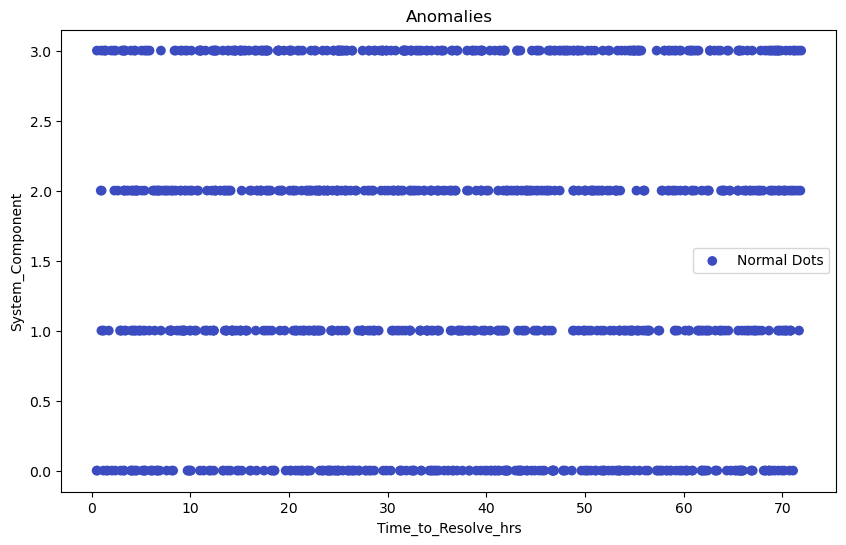

In [76]:
# Plot anomalies
plt.figure(figsize=(10, 6))
plt.scatter(dataset_classification['Time_to_Resolve_hrs'], dataset_classification['System_Component'], 
            c=dataset_classification['Anomaly'], cmap='coolwarm', label='Normal Dots')
plt.xlabel('Time_to_Resolve_hrs')
plt.ylabel('System_Component')
plt.title('Anomaly')
plt.legend()
plt.show()


In [77]:
anomaly_results.shape

(0, 13)

# Q5

In [78]:
import math
from math import sqrt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [79]:
dataset_retail=pd.read_csv('C:/Users/maame/Downloads/IT_Retail_List (1).csv')
dataset_retail

,InvoiceNo,ItemCode,Most popular item of the day,Quantity,Date,UnitPrice,CustomerID
0,1.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01/12/2018,2.55,43009.0
1,2.0,71053,WHITE METAL LANTERN,6.0,02/12/2018,3.39,79874.0
2,3.0,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,03/12/2018,2.75,45061.0
3,4.0,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,04/12/2018,3.39,47110.0
4,5.0,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,05/12/2018,3.39,77834.0
...,...,...,...,...,...,...,...
1623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1626,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
dataset_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   InvoiceNo                     1000 non-null   float64
 1   ItemCode                      1000 non-null   object 
 2   Most popular item of the day  999 non-null    object 
 3   Quantity                      1000 non-null   float64
 4   Date                          1000 non-null   object 
 5   UnitPrice                     1000 non-null   float64
 6   CustomerID                    1000 non-null   float64
dtypes: float64(4), object(3)
memory usage: 89.2+ KB


In [81]:
dataset_retail.isnull().sum()

InvoiceNo                       628
ItemCode                        628
Most popular item of the day    629
Quantity                        628
Date                            628
UnitPrice                       628
CustomerID                      628
dtype: int64

In [82]:
dataset_retail.dropna(subset=['CustomerID'],inplace=True)

In [83]:
dataset_retail.dropna(subset=['Quantity'],inplace=True)

In [84]:
dataset_retail.dropna(subset=['Date'],inplace=True)

In [85]:
dataset_retail.dropna(subset=['UnitPrice'],inplace=True)

In [86]:
dataset_retail.dropna(subset=['Most popular item of the day'],inplace=True)

In [87]:
dataset_retail.dropna(subset=['InvoiceNo'],inplace=True)

In [88]:
dataset_retail.isnull().sum()

InvoiceNo                       0
ItemCode                        0
Most popular item of the day    0
Quantity                        0
Date                            0
UnitPrice                       0
CustomerID                      0
dtype: int64

In [89]:
# recommendation system
# customer id is converted into string to facillitate the algorithm here

dataset_retail['CustomerID'] = dataset_retail['CustomerID'].astype(str)

In [90]:
#  identifying the values that is greater than zero(if there is return, it will show as a negative number)
# price and Quantity.

dataset_retail = dataset_retail[(dataset_retail['Quantity']>0) & (dataset_retail['UnitPrice']>0)]

In [91]:
#Now we will create the User_item matrix --> Understanding the behaviour of the user regarding the items

user_item_matrix = dataset_retail.pivot_table(index='CustomerID', columns = 'ItemCode', values = 'Quantity', aggfunc = 'sum').fillna(0)
user_item_matrix.head()

ItemCode,10002,10125,10133,15056BL,15056N,16014,16016,16237,16238,16258A,...,90059E,90129F,90185C,90199C,90200A,90200B,90200C,90200D,90210B,POST
CustomerID,,,,,,,,,,,,,,,,,,,,,
10563.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10666.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10745.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10807.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11068.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
# we will create the similarity metrics

user_similarity =cosine_similarity(user_item_matrix)

In [93]:
# display the similaries in a dataframe to make it easier to read
#Display the similarities in a dataframe to make it easier to read

user_similarity_df = pd.DataFrame(user_similarity, index = user_item_matrix.index, columns = user_item_matrix.index)

In [94]:
user_similarity_df.head()

CustomerID,10563.0,10666.0,10745.0,10807.0,11068.0,11442.0,11623.0,11851.0,12345.0,12769.0,...,99039.0,99059.0,99124.0,99195.0,99208.0,99295.0,99451.0,99580.0,99612.0,99866.0
CustomerID,,,,,,,,,,,,,,,,,,,,,
10563.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10666.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10745.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10807.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.041631,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11068.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
# Rating the predictions using the matrix user_item

#Rating prediction using the matrix user_item

def predict_ratings_user_based(user_item_matrix, user_similarity):
    mean_user_rating = user_item_matrix.mean(axis = 1).values
    rating_diff = (user_item_matrix.values - mean_user_rating[:, np.newaxis])
    pred = mean_user_rating[:, np.newaxis] + user_similarity.dot(rating_diff)/np.array([np.abs(user_similarity).sum(axis=1)]).T
    return pred

In [96]:
#Predicted ratings

user_predicted_ratings = predict_ratings_user_based(user_item_matrix, user_similarity)
user_predicted_ratings

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.01962457,  0.01962457,  0.01962457, ...,  0.01962457,
         0.01962457,  0.01962457],
       [ 0.01138035,  0.01138035,  0.01138035, ...,  0.01138035,
         0.01138035,  0.01138035],
       ...,
       [-0.02167458, -0.02167458, -0.02167458, ..., -0.02167458,
        -0.02167458, -0.02167458],
       [-0.0016948 , -0.0016948 , -0.0016948 , ..., -0.0016948 ,
        -0.0016948 , -0.0016948 ],
       [-0.00838519, -0.00838519, -0.00838519, ..., -0.00838519,
        -0.00838519, -0.00838519]])

In [97]:
#Checking the performance of the algorithm , the results of 17 mean is 17% mistakes or wrong
def rmse(prediction, ground_truth):
    prediction = prediction[ground_truth.nonzero()].flatten()
    ground_truth = ground_truth[ground_truth.nonzero()].flatten()
    return sqrt(mean_squared_error(prediction, ground_truth))

print('User-user collaborative error:', rmse(user_predicted_ratings, user_item_matrix.values))

User-user collaborative error: 17.370611329377493


In [98]:
#We create an item similarity matrix

item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index = user_item_matrix.columns, columns = user_item_matrix.columns)

In [99]:
#Rating for the item collaboration

def predict_ratings_item_based(user_item_matrix, item_similarity):
    pred = user_item_matrix.values.dot(item_similarity) / np.array([np.abs(item_similarity).sum(axis=1)])
    return pred

#Predict the ratings
item_predicted_ratings = predict_ratings_item_based(user_item_matrix, item_similarity)

#We print the accuracy
print('Item-item collaborative error:', rmse(item_predicted_ratings, user_item_matrix.values))

Item-item collaborative error: 17.38133841207562


In [100]:
from scipy.sparse.linalg import svds

In [101]:
#Normalise the data to have the same unit of measurement

user_ratings_mean = np.mean(user_item_matrix.values, axis = 1)
ratings_demeaned = user_item_matrix.values - user_ratings_mean.reshape(-1,1)

In [102]:
# singular value the Decomposition(SVD)
U,sigma,vt= svds(ratings_demeaned, k=50)
sigma=np.diag(sigma)

In [103]:
#Rating prediction
all_user_predicted_ratings = np.dot(np.dot(U, sigma), vt) + user_ratings_mean.reshape(-1,1)
predicted_ratings_df = pd.DataFrame(all_user_predicted_ratings, columns = user_item_matrix.columns)

In [104]:
#Evaluation of the model after the SVD
print('SVD collaborative filtering', rmse(predicted_ratings_df.values, user_item_matrix.values))

SVD collaborative filtering 8.88860319449212


In [105]:
#Now, with this results, we can move on to the recommendations. Let's say that we want to recommend 3 items

def recommended_items(user_id, user_item_matrix, predicted_ratings_df, num_recommendations = 3):
    user_idx = user_item_matrix.index.get_loc(user_id) #sorting the user predicted ratings
    sorted_user_ratings = predicted_ratings_df.iloc[user_idx].sort_values(ascending = False)
    user_data = user_item_matrix.loc[user_id] #appending or merging the user data with the sorted ratings
    user_full = (user_data[user_data >0]).sort_values(ascending = False)
    recommendations = sorted_user_ratings[~sorted_user_ratings.index.isin(user_full.index)]
    return recommendations.head(num_recommendations) # recommendation of items that the user did not buy yet

In [106]:
#To see the recommendations, we need to select a random user because recommendations will change user by user

random_user_index = np.random.choice(user_item_matrix.index) #I select a random user

customer_id = random_user_index
customer_id

'94507.0'

In [107]:
def normalize_ratings(predicted_ratings):
    min_rating = predicted_ratings.min()
    max_rating = predicted_ratings.max()
    probabilities = (predicted_ratings - min_rating) / (max_rating - min_rating)
    return probabilities

In [108]:
recommendations = recommended_items(random_user_index, user_item_matrix, predicted_ratings_df, num_recommendations = 3)

In [109]:
#Normalise the predicted ratings to get probabilities
recommendation_probabilities = normalize_ratings(recommendations)

# Display the recommendations and their probabilities
print("Recommendations for customer ID:", customer_id)
print(recommendation_probabilities)

Recommendations for customer ID: 94507.0
ItemCode
22963    1.000000
22059    0.866667
21086    0.000000
Name: 742, dtype: float64


In [116]:
#We convert the stock codes into strings

dataset_retail['ItemCode'] = dataset_retail['ItemCode'].astype(str)

C:\Users\maame\AppData\Local\Temp\ipykernel_13620\3773324245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_retail['ItemCode'] = dataset_retail['ItemCode'].astype(str)


In [117]:
ItemCode=['22963','22059','21086']

In [119]:
#We dipsplay the results in a dataframe

filtered_data = dataset_retail[dataset_retail['ItemCode'].isin(['22963','22059','21086'])]
filtered_data

,InvoiceNo,ItemCode,Most popular item of the day,Quantity,Date,UnitPrice,CustomerID
215,216.0,22963,JAM JAR WITH GREEN LID,48.0,04/07/2019,0.72,45453.0
226,227.0,21086,SET/6 RED SPOTTY PAPER CUPS,48.0,15/07/2019,0.65,29094.0
731,732.0,22059,CERAMIC STRAWBERRY DESIGN MUG,48.0,01/12/2020,1.25,46523.0


In [124]:
prob_dataset_retail=dataset_retail.copy()
prob_dataset_retail["ItemCode"]= prob_dataset_retail["ItemCode"].astype(str)


In [125]:
final_result_df = pd.merge(filtered_data[['ItemCode','Most popular item of the day']].drop_duplicates(), prob_dataset_retail, on = 'ItemCode')
final_result_df

,ItemCode,Most popular item of the day_x,InvoiceNo,Most popular item of the day_y,Quantity,Date,UnitPrice,CustomerID
0,22963,JAM JAR WITH GREEN LID,216.0,JAM JAR WITH GREEN LID,48.0,04/07/2019,0.72,45453.0
1,21086,SET/6 RED SPOTTY PAPER CUPS,227.0,SET/6 RED SPOTTY PAPER CUPS,48.0,15/07/2019,0.65,29094.0
2,22059,CERAMIC STRAWBERRY DESIGN MUG,732.0,CERAMIC STRAWBERRY DESIGN MUG,48.0,01/12/2020,1.25,46523.0
